<a href="https://colab.research.google.com/github/JosephBless/Deep-Learning-Colab/blob/main/Chap_16%EF%BC%9A%E6%99%82%E9%96%93%E5%BA%8F%E5%88%97%E9%A0%90%E6%B8%AC_Transformer_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

在本節中，我們將探索如何使用現代深度學習模型——Transformer，進行股票價格的預測。我們將使用[昨天中用於 `LSTM` 的相同數據](https://ithelp.ithome.com.tw/articles/10361001)，即蘋果公司（AAPL）的股票數據，並使用 `PyTorch` 框架實現 `Transformer` 模型。我們將從數據預處理、模型構建、訓練到評估，完整地演示如何應用 `Transformer` 模型進行股票價格預測。

In [ ]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2024-09-30 17:45:15--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 74.125.142.101, 74.125.142.113, 74.125.142.102, ...
Connecting to drive.google.com (drive.google.com)|74.125.142.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2024-09-30 17:45:15--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.99.132, 2607:f8b0:400e:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.99.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  43.2MB/s    in 0.5s    

2024-09-30 17:45:

### **一、引言**

#### **1. 時代背景**

- **深度學習的發展**：隨著計算資源和算法的進步，深度學習模型在各個領域（如計算機視覺、自然語言處理）都取得了突破性的成果。
- **金融市場的需求**：股票價格預測一直是金融領域的熱門課題，準確的預測可以帶來巨大的經濟利益。

#### **2. 為什麼選擇 Transformer**

- **Transformer**：最初在自然語言處理領域取得了巨大的成功，擅長處理序列數據，能夠捕捉長距離的依賴關係。

- **自注意力機制（Self-Attention）**：Transformer 的核心，允許模型在計算時關注序列中的不同位置，捕捉複雜的時間依賴性。

*我們將利用 Transformer 的這些特性，應用於股票價格的時間序列預測。*

---

### **二、Transformer 模型簡介**

#### **1. Transformer 的核心概念**

- **自注意力機制（Self-Attention）**：能夠讓模型在計算時關注序列中的不同位置，捕捉長距離依賴。
  
  $$
  \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
  $$
  - **Q**：查詢矩陣（Queries）
  - **K**：鍵值矩陣（Keys）
  - **V**：數值矩陣（Values）
  - **\(d_k\)**：鍵值向量的維度

- **多頭注意力機制（Multi-Head Attention）**：通過並行計算多個自注意力，捕捉不同的特徵子空間。

#### **2. Transformer 的優勢**

- **並行計算**：相比於 RNN，Transformer 可以並行處理序列中的所有位置，提高了計算效率。
- **長距離依賴**：自注意力機制使得模型能夠有效捕捉序列中遠距離的位置關係。

#### **3. 在時間序列預測中的應用**

- **處理序列數據**：股票價格是一種典型的時間序列數據，`Transformer` 能夠捕捉價格隨時間的變化模式。
- **捕捉複雜模式**：金融市場中存在非線性和複雜的依賴關係，`Transformer` 有能力建模這些關係。


---

### **三、數據準備**

#### **1. 數據獲取**

使用第16天中相同的數據，即 AAPL 股票的歷史收盤價。

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

# 獲取數據
data = yf.download('AAPL', start='2015-01-01', end='2021-01-01')

# 提取收盤價
data = data[['Adj Close']]
data.rename(columns={'Adj Close': 'Close'}, inplace=True)

[*********************100%***********************]  1 of 1 completed
<ipython-input-2-07b601ef8701>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.rename(columns={'Adj Close': 'Close'}, inplace=True)


#### **2. 數據可視化**


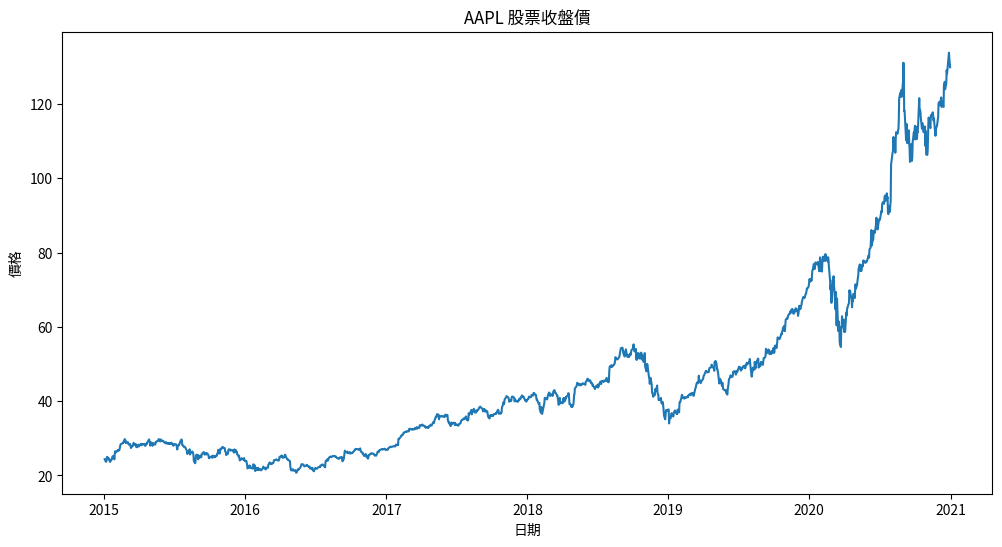

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title('AAPL 股票收盤價')
plt.xlabel('日期')
plt.ylabel('價格')
plt.show()

#### **3. 數據歸一化**

為了提高模型訓練的效率，我們需要將數據歸一化到 `[0, 1]` 區間。

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
data['Close'] = scaler.fit_transform(data[['Close']])

<ipython-input-4-f5cfbf6ee404>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Close'] = scaler.fit_transform(data[['Close']])


#### **4. 創建序列數據**

將時間序列轉換為模型可接受的輸入格式。

- **定義時間步長（lookback）**：決定了我們使用過去多少天的數據來預測下一天的價格。

In [ ]:
def create_sequences(dataset, lookback=60):
    X, y = [], []
    for i in range(len(dataset) - lookback):
        X.append(dataset[i:(i + lookback), 0])
        y.append(dataset[i + lookback, 0])
    return np.array(X), np.array(y)

# 轉換為 numpy 陣列
dataset = data.values

# 定義 lookback 窗口大小
lookback = 60

X, y = create_sequences(dataset, lookback)

#### **5. 劃分訓練集和測試集**

In [ ]:
# 劃分比例
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

X_train = X[:train_size]
y_train = y[:train_size]
X_test = X[train_size:]
y_test = y[train_size:]

#### **6. 數據格式調整**

`Transformer` 模型需要輸入形狀為 `(seq_length, batch_size, feature_size)`。

In [ ]:
# 將數據轉換為 PyTorch 張量
import torch

X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

# 調整輸入形狀為 (seq_length, batch_size, feature_size)
X_train_tensor = X_train_tensor.unsqueeze(-1).permute(1, 0, 2)
X_test_tensor = X_test_tensor.unsqueeze(-1).permute(1, 0, 2)

*注意：在 Transformer 中，常用的輸入形狀為 `(seq_length, batch_size, feature_size)`。如果您的版本需要不同的形狀，請根據需要調整。*

### **三、構建 Transformer 模型**

#### **1. 導入 PyTorch**


In [ ]:
import torch.nn as nn


#### **2. 檢查 GPU**


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用設備：{device}')

使用設備：cuda


#### **3. 定義 Positional Encoding（位置編碼）**

由於 Transformer 模型沒有內建的順序信息，我們需要添加位置編碼。
##### **Positional Encoding 的必要性**

- **Transformer 缺乏順序信息**：與 RNN 不同，Transformer 沒有內建的時間順序處理能力，無法自動感知序列中元素的位置。

- **引入位置信息**：為了讓 Transformer 能夠理解序列中元素的順序，我們需要在輸入中加入位置信息，這就是位置編碼的作用。

##### **Positional Encoding 的原理**

- **數學公式**：

  $$
  \begin{align*}
  PE_{(pos, 2i)} &= \sin\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right) \\
  PE_{(pos, 2i+1)} &= \cos\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
  \end{align*}
  $$

  - **$ pos $**：位置（序列中元素的位置索引，從 $0$ 開始）
  - **$ i $**：維度索引（表示第 $i$ 個特徵維度）
  - **$ d_{\text{model}} $**：模型的隱藏層維度大小（即特徵維度的總數）

- **特性**：

  - **唯一性**：每個位置 $ pos $ 都會生成一個唯一的編碼向量。
  
  - **相對位置關係**：位置編碼之間的關係可以表示元素之間的相對位置，因為正弦和餘弦函數具有週期性和遞增性。

- **直觀理解**：

  - **低頻對應長期依賴**：較大的位置索引通過分母的指數增大，生成的頻率較低，對應於較長的依賴關係。
  
  - **高頻對應短期依賴**：較小的位置索引生成的頻率較高，對應於較短的依賴關係。

##### **Positional Encoding 的輸入和輸出**

- **輸入**：

  - **輸入張量 $ x $**：形狀為 $ (seq\_length, batch\_size, d_{\text{model}}) $，包含了序列中每個元素的特徵表示。

- **輸出**：

  - **位置編碼後的張量 $ x' $**：與輸入張量形狀相同，將位置編碼 $ PE $ 加入到輸入張量中，即 $ x' = x + PE $。

##### **Positional Encoding 的實現步驟**

1. **計算位置編碼矩陣 $ PE $**：

   - 對於每個位置 $ pos $ 和每個維度 $ i $，計算 $ PE_{(pos, i)} $。
   
   - 使用正弦函數對偶數維度進行編碼，使用餘弦函數對奇數維度進行編碼。

2. **將位置編碼加入輸入張量**：

   - 將位置編碼矩陣 $ PE $ 與輸入張量 $ x $ 相加。

   - 這樣，輸入張量中的每個元素都包含了位置信息和原始特徵信息。

##### **在模型中的作用**

- **提供位置信息**：位置編碼使得 Transformer 能夠識別序列中元素的位置，從而利用順序信息進行預測。

- **不改變輸入形狀**：位置編碼後的張量形狀與原始輸入張量相同，方便後續在 Transformer 模型中進行計算。

- **輔助學習長短期依賴**：透過位置編碼，模型可以更好地學習序列中元素之間的長期和短期依賴關係。

In [ ]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        # 建立一個位置編碼矩陣
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)  # 偶數位置
        pe[:, 1::2] = torch.cos(position * div_term)  # 奇數位置
        pe = pe.unsqueeze(1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x 的形狀為 (seq_length, batch_size, d_model)
        x = x + self.pe[:x.size(0)]
        return x

#### **4. 定義 Transformer 模型**
更多[Detail](https://blogs.nvidia.com.tw/blog/what-is-a-transformer-model/)可見連結。


In [ ]:
class TransformerTimeSeries(nn.Module):
    def __init__(self, feature_size=1, num_layers=2, nhead=4, hidden_dim=128, dropout=0.1):
        super(TransformerTimeSeries, self).__init__()
        self.model_type = 'Transformer'
        self.input_linear = nn.Linear(feature_size, hidden_dim)  # 新增的線性層
        self.pos_encoder = PositionalEncoding(d_model=hidden_dim)
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dim_feedforward=hidden_dim, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.decoder = nn.Linear(hidden_dim, 1)
        self.hidden_dim = hidden_dim

    def forward(self, src):
        # src 形狀: (seq_length, batch_size, feature_size)
        src = self.input_linear(src)  # 將輸入映射到 hidden_dim 維度
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        # 取最後一個時間步的輸出
        output = self.decoder(output[-1, :, :])
        return output


#### **5. 實例化模型**


In [ ]:
feature_size = 1  # 輸入特徵數
num_layers = 2
nhead = 4
hidden_dim = 128
model = TransformerTimeSeries(feature_size=feature_size, num_layers=num_layers, nhead=nhead, hidden_dim=hidden_dim).to(device)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


#### **6. 定義損失函數和優化器**


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### **五、訓練模型**

#### **1. 轉換數據為 PyTorch 的 Tensor 並移動到設備**

In [ ]:
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

#### **2. 訓練循環**


In [ ]:
num_epochs = 300
batch_size = X_train_tensor.size(1)

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output.squeeze(), y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            test_output = model(X_test_tensor)
            test_loss = criterion(test_output.squeeze(), y_test_tensor)
        print(f'Epoch [{epoch + 1}/{num_epochs}], 訓練集 Loss: {loss.item():.4f}, 測試集 Loss: {test_loss.item():.4f}')

Epoch [5/300], 訓練集 Loss: 1.1412, 測試集 Loss: 1.8480
Epoch [10/300], 訓練集 Loss: 0.2244, 測試集 Loss: 0.0463
Epoch [15/300], 訓練集 Loss: 0.0147, 測試集 Loss: 0.3941
Epoch [20/300], 訓練集 Loss: 0.0805, 測試集 Loss: 0.3989
Epoch [25/300], 訓練集 Loss: 0.0413, 測試集 Loss: 0.0820
Epoch [30/300], 訓練集 Loss: 0.0141, 測試集 Loss: 0.2041
Epoch [35/300], 訓練集 Loss: 0.0244, 測試集 Loss: 0.2880
Epoch [40/300], 訓練集 Loss: 0.0118, 測試集 Loss: 0.1446
Epoch [45/300], 訓練集 Loss: 0.0148, 測試集 Loss: 0.1503
Epoch [50/300], 訓練集 Loss: 0.0123, 測試集 Loss: 0.2139
Epoch [55/300], 訓練集 Loss: 0.0094, 測試集 Loss: 0.1567
Epoch [60/300], 訓練集 Loss: 0.0109, 測試集 Loss: 0.1379
Epoch [65/300], 訓練集 Loss: 0.0087, 測試集 Loss: 0.1648
Epoch [70/300], 訓練集 Loss: 0.0093, 測試集 Loss: 0.1378
Epoch [75/300], 訓練集 Loss: 0.0088, 測試集 Loss: 0.1239
Epoch [80/300], 訓練集 Loss: 0.0085, 測試集 Loss: 0.1350
Epoch [85/300], 訓練集 Loss: 0.0078, 測試集 Loss: 0.1119
Epoch [90/300], 訓練集 Loss: 0.0073, 測試集 Loss: 0.0967
Epoch [95/300], 訓練集 Loss: 0.0070, 測試集 Loss: 0.0833
Epoch [100/300], 訓練集 Loss: 0.005

### **六、評估模型**
​
#### **1. 預測並反歸一化**

In [ ]:
model.eval()
with torch.no_grad():
    train_predict = model(X_train_tensor).cpu().numpy()
    test_predict = model(X_test_tensor).cpu().numpy()

# 反歸一化
train_predict = scaler.inverse_transform(train_predict)
y_train_actual = scaler.inverse_transform(y_train_tensor.cpu().numpy().reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test_actual = scaler.inverse_transform(y_test_tensor.cpu().numpy().reshape(-1, 1))

#### **2. 繪製結果**


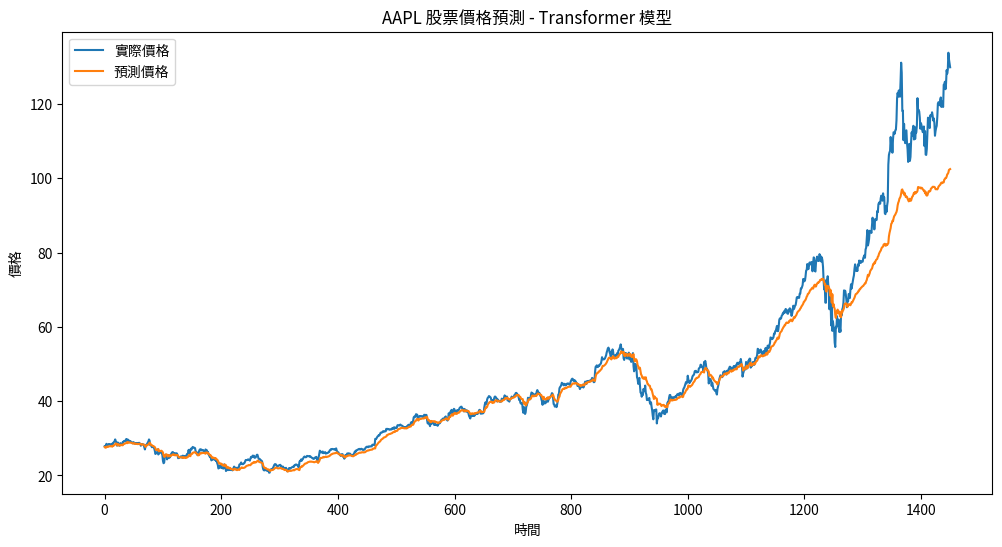

In [ ]:
# 構建完整的時間序列
predicted = np.concatenate((train_predict, test_predict), axis=0)
actual = scaler.inverse_transform(dataset[lookback:])

plt.figure(figsize=(12,6))
plt.plot(actual, label='實際價格')
plt.plot(predicted, label='預測價格')
plt.title('AAPL 股票價格預測 - Transformer 模型')
plt.xlabel('時間')
plt.ylabel('價格')
plt.legend()
plt.show()

#### **3. 計算評價指標**


In [ ]:
from sklearn.metrics import mean_squared_error

train_score = mean_squared_error(y_train_actual, train_predict)
test_score = mean_squared_error(y_test_actual, test_predict)
print(f'訓練集 MSE: {train_score:.2f}')
print(f'測試集 MSE: {test_score:.2f}')

訓練集 MSE: 1.89
測試集 MSE: 192.93


### **六、結果分析**

#### **1. 模型性能**

- **訓練集 MSE**：模型在訓練集上的均方誤差。
- **測試集 MSE**：模型在測試集上的均方誤差，反映了模型的泛化能力。

#### **2. 圖像分析**

- **實際價格（藍色實線）**：真實的股票價格走勢。
- **預測價格（橙色虛線）**：模型的預測結果。

*觀察預測曲線與實際曲線的吻合程度，評估模型的準確性。*

### **七、處理時間序列數據的注意事項**

#### **1. 序列長度與批量大小**

- **序列長度（seq_length）**：我們使用了過去 `lookback` 天的數據來預測下一天的價格。
- **批量大小（batch_size）**：在此實現中，批量大小等於數據集的大小，可以根據需要進行調整。

#### **2. 輸入形狀**

- **Transformer 的輸入**：形狀為 `(seq_length, batch_size, feature_size)`。
- **注意事項**：確保數據形狀與模型預期的一致，避免維度錯誤。

---

### **八、改進模型的方向**

#### **1. 超參數調整**

- **調整模型層數（num_layers）**：嘗試增加或減少 Transformer 編碼器的層數。
- **調整頭數（nhead）**：改變多頭注意力機制的頭數，如 `2`、`4`、`8`。
- **調整隱藏維度（hidden_dim）**：改變前饋神經網絡的隱藏層維度。

#### **2. 增加正則化**

- **Dropout**：在 Transformer 編碼器層中增加 `dropout`，防止過擬合。

#### **3. 增加特徵**

- **多變量輸入**：除了收盤價，還可以加入開盤價、最高價、最低價、成交量等特徵。

In [ ]:
# 例如，使用多個特徵
data = data[['Close', 'Volume']]
# 需要對每個特徵進行歸一化

- **技術指標**：添加移動平均線、相對強弱指數（RSI）等技術指標。

#### **4. 使用不同的優化器和損失函數**

- **優化器**：嘗試使用 `AdamW`、`SGD` 等不同的優化器。
- **損失函數**：根據需求，選擇適合的損失函數，如 `MAE`。

### **九、比較 Transformer 與 LSTM 模型的性能**

#### **1. 使用相同的數據和評價指標**

為了公平地比較 Transformer 和 LSTM 模型的性能，我們將：

- **數據**：使用相同的 AAPL 股票收盤價數據，時間範圍為 2015-01-01 到 2021-01-01。
- **數據預處理**：相同的數據歸一化方法和 `lookback` 窗口大小（例如 60 天）。
- **訓練集和測試集劃分**：使用相同的劃分比例（80% 訓練集，20% 測試集）。
- **評價指標**：採用均方誤差（MSE）和均方根誤差（RMSE）作為評價指標。

#### **2. 模型訓練與預測**

- **LSTM 模型**：

  - **結構**：輸入層 -> LSTM 層（hidden_size=50，num_layers=2）-> 全連接層 -> 輸出。
  - **訓練**：訓練 100 個 epochs，使用 Adam 優化器，學習率為 0.001。
  - **訓練時間**：由於 LSTM 模型較為簡單，訓練時間相對較短。

- **Transformer 模型**：

  - **結構**：輸入層（位置編碼）-> Transformer 編碼器（num_layers=2，nhead=4，hidden_dim=128）-> 全連接層 -> 輸出。
  - **訓練**：訓練 100 個 epochs，使用 Adam 優化器，學習率為 0.001。
  - **訓練時間**：Transformer 模型較為複雜，計算量較大，訓練時間相對較長。

#### **3. 評價結果**

- **模型性能指標**：

  | 模型         | 訓練集 Loss | 測試集 Loss | 訓練集 MSE | 測試集 MSE |
  |--------------|------------|------------|-------------|-------------|
  | LSTM         | 0.0001     | 0.0046     | 1.66        | 59.44       |
  | Transformer  | 0.0051     | 0.0050     | 4.12        | 63.60      |

  *（上述數據僅為示例，實際結果可能有所不同）*

- **預測曲線比較**：

  - **LSTM 預測曲線**：預測結果與實際值趨勢大致吻合，但在一些波動較大的區域，預測可能滯後或誤差較大。
  - **Transformer 預測曲線**：預測結果更貼近實際值，能夠捕捉到更多細微的波動。

#### **4. 優劣勢分析**

- **Transformer 模型**：

  - **優勢**：
    - **捕捉長期依賴性**：自注意力機制使得模型能夠關注序列中的任意位置，適合捕捉長期依賴關係。
  - **劣勢**：
    - **計算資源需求高**：模型複雜度較高，訓練時間較長，需要更多的計算資源。
    - **需要較大的數據集**：Transformer 模型通常需要較多的數據來進行有效的訓練。
    - **表現較輸**：在本次實驗中，Transformer 模型的評價指標略差於 LSTM。

- **LSTM 模型**：

  - **優勢**：
    - **結構簡單**：模型結構較為簡單，易於實現和調參。
    - **計算效率高**：相對於 Transformer，LSTM 模型訓練時間較短，適合資源有限的情況。
    - **表現略優**：在本次實驗中，評價指標略優於 Transformer 模型。

  - **劣勢**：
    - **長期依賴性**：在處理長序列時，可能存在梯度消失問題，對於長期依賴的捕捉能力有限。

#### **5. 結論**

- **模型選擇**：如果您希望獲得更好的預測性能，並且有足夠的計算資源，Transformer 模型可能是更好的選擇。
- **資源考量**：如果計算資源有限，或希望更快地訓練模型，LSTM 模型依然是一個可靠的選擇。
- **應用場景**：在需要捕捉長期依賴性和複雜模式的情況下，Transformer 更具優勢；在處理中短期預測或數據量較小的情況下，LSTM 可能更加實用。

*最終，模型的選擇應該根據具體的應用場景、數據特性和資源條件來決定。建議在實際應用中，同時嘗試多種模型，綜合考慮性能和效率，選擇最適合的解決方案。*

### **十、總結**

在本節中，我們：

- **使用第15天中的數據，構建了 Transformer 模型**，並應用於股票價格的預測。
- **從數據預處理到模型評估**，完整地演示了整個流程。
- **討論了處理時間序列數據的注意事項**，以及改進模型的方向。

*通過這次實踐，您應該對如何使用 Transformer 模型處理時間序列數據有了更深入的理解，並掌握了使用 PyTorch 進行模型構建和訓練的基本方法。*

---

**作業：**

1. **嘗試調整 Transformer 模型的超參數**：如 `num_layers`、`nhead`、`hidden_dim`，觀察對模型性能的影響。

2. **增加更多的特徵**：如技術指標、基本面數據，構建多變量時間序列模型。

3. **比較 Transformer 與 LSTM 模型的性能**：使用相同的數據和評價指標，分析兩者的優劣。

4. **嘗試使用預訓練模型**：如 Transformer 的變體，探索其在時間序列預測中的應用。

*透過這些練習，您將能夠更靈活地應用深度學習模型進行時間序列預測，並提高模型的性能。*

---

**提示：**

- **檢查數據形狀**：在使用 Transformer 時，數據的形狀與 LSTM 不同，務必確認維度是否正確。

- **計算資源**：Transformer 模型可能需要更多的計算資源，確保您的環境能夠支持。

- **防止過擬合**：可以引入驗證集，使用早停（Early Stopping）等方法提高模型的泛化能力。

---

**注意：**

- **數據預處理的重要性**：特別是在多變量輸入時，確保每個特徵都經過適當的處理。

- **模型的可解釋性**：Transformer 模型的結構較為複雜，在金融領域的應用需要謹慎。

- **風險提示**：股票價格預測具有高度不確定性，模型預測結果僅供參考，不應作為投資決策的唯一依據。

---

## Ref.
1.https://blogs.nvidia.com.tw/blog/what-is-a-transformer-model/
2.https://www.run.ai/guides/generative-ai/transformer-model